##Exp-9


In [1]:
!pip install scikit-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/AML_Lab_B19/Exp-9 Classification Model/mitbih_test.csv', header=None)

# Assume the last column is the target and rename it to 'Label'
df = df.rename(columns={df.columns[-1]: 'Label'})

# Target column: Normal / Abnormal
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])   # Normal=0, Abnormal=1

X = df.drop('Label', axis=1)
y = df['Label']

class_counts = y.value_counts()
single_sample_classes = class_counts[class_counts < 2].index
if not single_sample_classes.empty:
    df = df[~df['Label'].isin(single_sample_classes)]
    X = df.drop('Label', axis=1)
    y = df['Label']

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.fillna(X.mean())

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Decision Tree
Accuracy: 0.9303493948390044
Precision: 0.9314471868017169
Recall: 0.9303493948390044
F1 Score: 0.9307847508678375
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3624
           1       0.51      0.57      0.54       111
           2       0.80      0.75      0.78       290
           3       0.25      0.28      0.26        32
           4       0.91      0.89      0.90       322

    accuracy                           0.93      4379
   macro avg       0.69      0.69      0.69      4379
weighted avg       0.93      0.93      0.93      4379



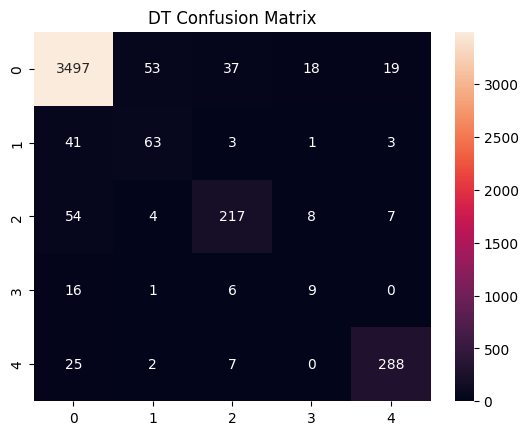

In [4]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1] # This might still be an issue if there are more than 2 classes

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_dt, average='weighted'))
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("DT Confusion Matrix")
plt.show()

# ROC
# For multiclass problems, ROC curve typically needs a one-vs-rest or one-vs-one approach
# or specific averaging. The current y_prob_dt[:,1] assumes binary classification.
# If you want to plot ROC for multiclass, consider a different approach or focusing on one class.
# For now, I'll comment out the ROC plotting as it's not directly compatible with multiclass predict_proba[:,1]
# fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
# auc_dt = auc(fpr_dt, tpr_dt)
# plt.plot(fpr_dt, tpr_dt, label=f"DT (AUC={auc_dt:.2f})")

Random Forest
Accuracy: 0.964832153459694
Precision: 0.9647510275616036
Recall: 0.964832153459694
F1 Score: 0.9620611027940197


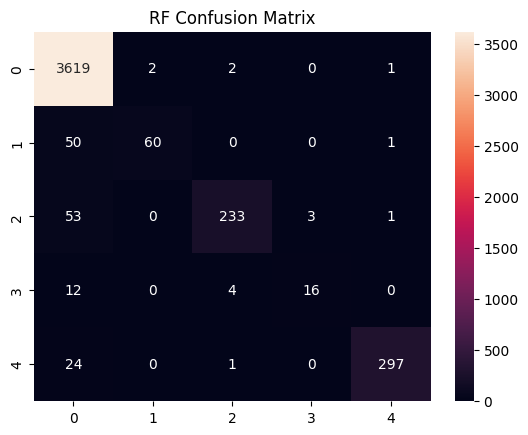

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("RF Confusion Matrix")
plt.show()

# For multiclass problems, ROC curve typically needs a one-vs-rest or one-vs-one approach
# or specific averaging. The current y_prob_rf[:,1] assumes binary classification.
# If you want to plot ROC for multiclass, consider a different approach or focusing on one class.
# fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
# auc_rf = auc(fpr_rf, tpr_rf)
# plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.2f})")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.9111669330897465
F1 Score: 0.8996886198409514


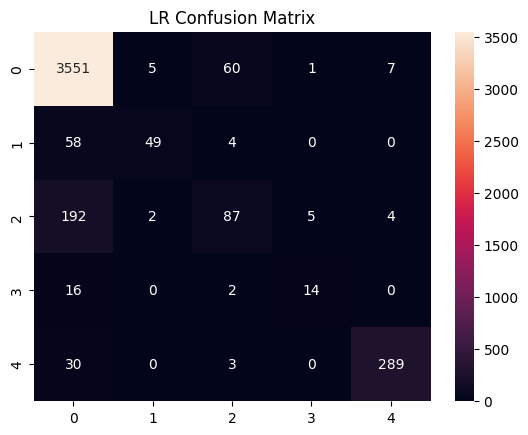

In [6]:
from sklearn.linear_model import LogisticRegression
import numpy as np # Ensure numpy is imported for nan_to_num

lr = LogisticRegression()

# Convert NaN values to zeros in X_train and X_test for Logistic Regression
X_train_cleaned = np.nan_to_num(X_train)
X_test_cleaned = np.nan_to_num(X_test)

lr.fit(X_train_cleaned, y_train)

y_pred_lr = lr.predict(X_test_cleaned)
y_prob_lr = lr.predict_proba(X_test_cleaned)[:,1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted')) # Fixed: Added average='weighted'

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("LR Confusion Matrix")
plt.show()

# For multiclass problems, ROC curve typically needs a one-vs-rest or one-vs-one approach
# or specific averaging. The current y_prob_lr[:,1] assumes binary classification.
# If you want to plot ROC for multiclass, consider a different approach or focusing on one class.
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = auc(fpr_lr, tpr_lr)
# plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={auc_lr:.2f})")

XGBoost
Accuracy: 0.9709979447362411
F1 Score: 0.9692785060102487


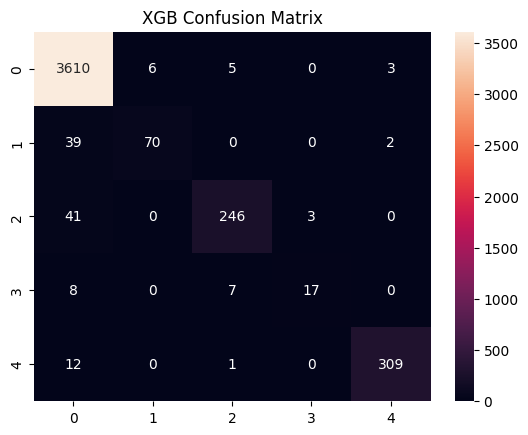

In [7]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss') # Removed use_label_encoder
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted')) # Fixed: Added average='weighted'

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title("XGB Confusion Matrix")
plt.show()

# For multiclass problems, ROC curve typically needs a one-vs-rest or one-vs-one approach
# or specific averaging. The current y_prob_xgb[:,1] assumes binary classification.
# If you want to plot ROC for multiclass, consider a different approach or focusing on one class.
# fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
# auc_xgb = auc(fpr_xgb, tpr_xgb)
# plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC={auc_xgb:.2f})")

KNN
Accuracy: 0.9598081753825074
F1 Score: 0.957771574082643


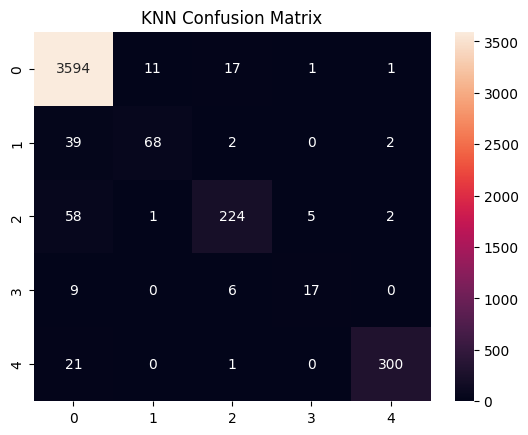

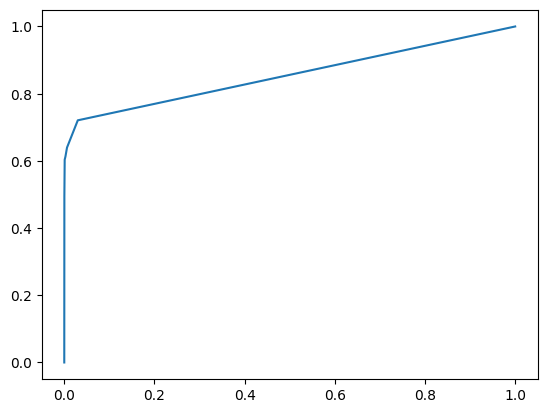

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn, average='weighted')) # Added average='weighted' for multiclass

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.show()

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn, pos_label=1) # Specify pos_label for multiclass ROC
auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.2f})")

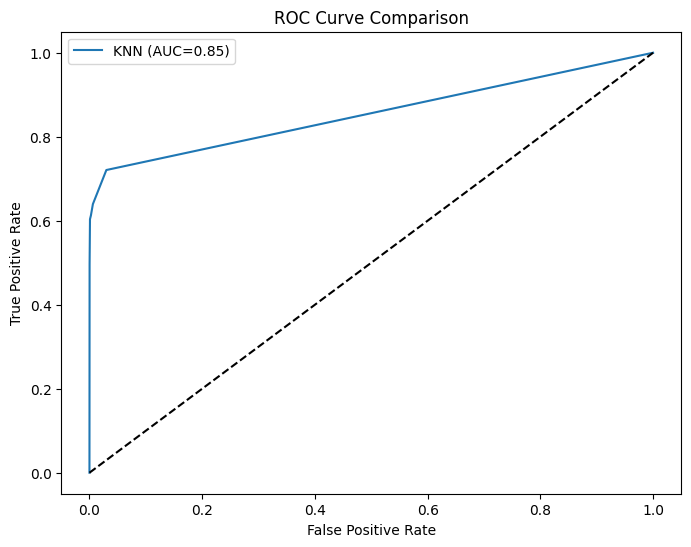

In [9]:
plt.figure(figsize=(8,6))

# plt.plot(fpr_dt, tpr_dt, label=f"DT (AUC={auc_dt:.2f})")
# plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.2f})")
# plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={auc_lr:.2f})")
# plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC={auc_xgb:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

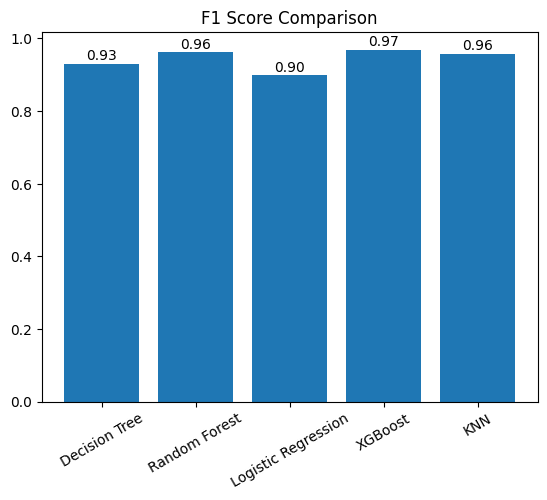

In [10]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

predictions = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "XGBoost": y_pred_xgb,
    "KNN": y_pred_knn
}

f1_scores = []
model_names = []

for name, y_pred in predictions.items():
    # Align lengths safely
    min_len = min(len(y_test), len(y_pred))

    y_test_aligned = y_test[:min_len]
    y_pred_aligned = y_pred[:min_len]

    score = f1_score(y_test_aligned, y_pred_aligned, average='weighted') # Added average='weighted'

    f1_scores.append(score)
    model_names.append(name)

# Plot
plt.bar(model_names, f1_scores)
plt.title("F1 Score Comparison")
plt.xticks(rotation=30)

for i, v in enumerate(f1_scores):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')

plt.show()